NEDO Quantum Challenge Season2 - IBM Seminar #1

# 量子コンピューターの使い方〜量子回路の作成から実機実行までの手順

Kifumi Numata, IBM Quantum (Oct 07, 2026)

コードセルは、セルを選択して「Shift」＋「Enter」、または上部の三角アイコンをクリックすると実行できます。

In [ ]:
# Qiskitバージョンの確認
import qiskit
qiskit.__version__

## 目次
1. 量子回路の作成
2. 量子シミュレーターでの実行
3. IBM Quantumで実行するための準備       
4. 実機の量子コンピューターで実行する     

# 1. 量子回路の作成
今回は、2量子ビットのもつれ状態（ベル状態）を例に回路を作成します。以下の回路で $\frac{ 1}{\sqrt{2}} (|00\rangle + |11\rangle)$ の状態を作ります。

In [ ]:
# ２量子ビット回路を作成します。
from qiskit import QuantumCircuit
qc = QuantumCircuit(2,2)    # 2量子ビット, 2古典ビットレジスター

# ゲートを適用します。
qc.h(0)
qc.cx(0,1)    # 制御NOTゲート

# 測定ゲートを追加
qc.measure(0,0)    # 量子ビットq0を測定して、古典レジスターc0に入れます
qc.measure(1,1)    # 量子ビットq1を測定して、古典レジスターc1に入れます

# 回路を描画
qc.draw(output="mpl")

# 2. 量子シミュレーターでの実行

まずはシミューレーターで実験してみます。Qiskit Aerを使います。

In [ ]:
# シミュレーターで実験
from qiskit_aer import AerSimulator
backend = AerSimulator()

from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler = Sampler(backend)
job = sampler.run([qc])  # デフォルトのshot数は1024です
result = job.result()

#  測定された回数を表示
counts = result[0].data.c.get_counts()
print(counts)

# ヒストグラムで測定された確率をプロット
from qiskit.visualization import plot_histogram
plot_histogram(counts)

# 3. IBM Quantumで実行するための準備

実量子コンピューターで実験するため次の手順で、API keyとCRNを次のセルのコードに入力してください。

1) https://quantum.cloud.ibm.com/ にサインインし、左側 「API key」の横にある「Create +」をクリックします。

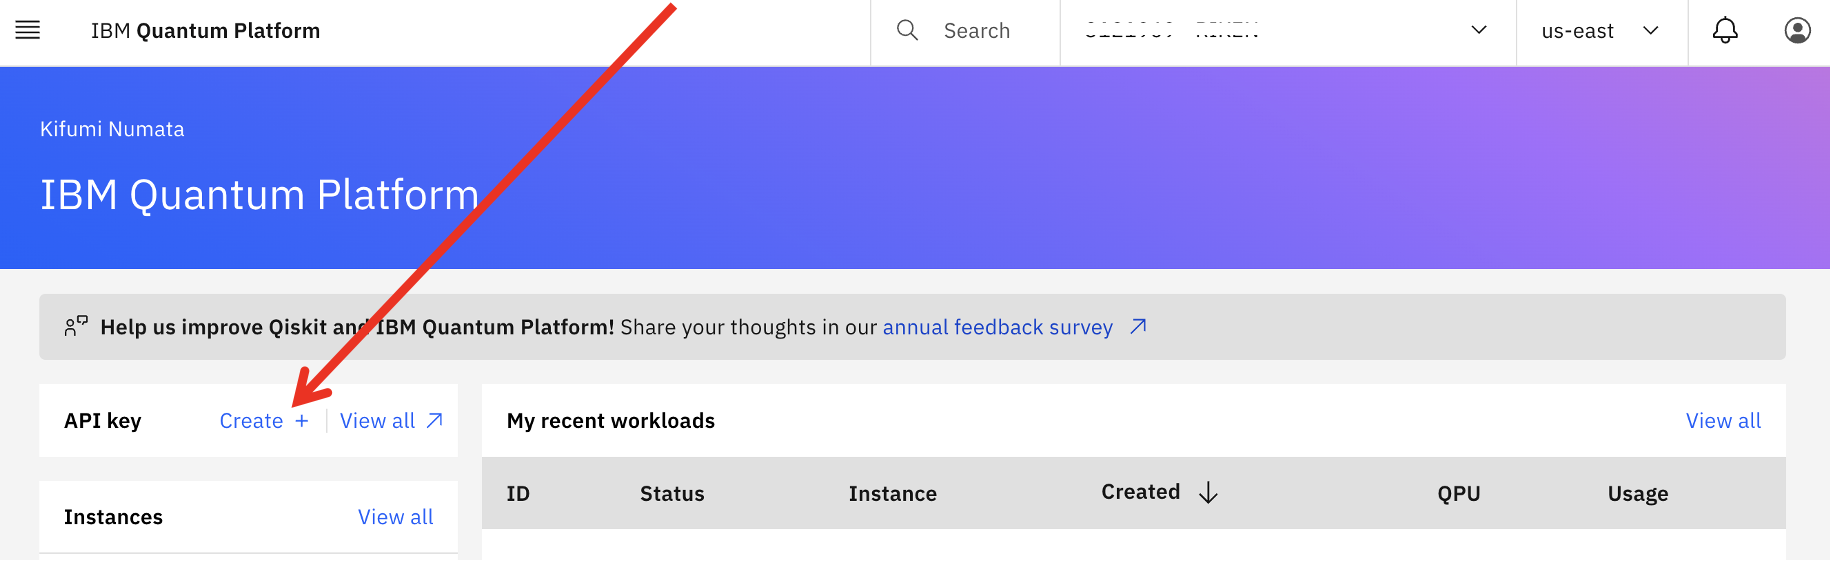

2) API keyの名前（例：my API など）を自由に入力し、「Create」をクリックします。
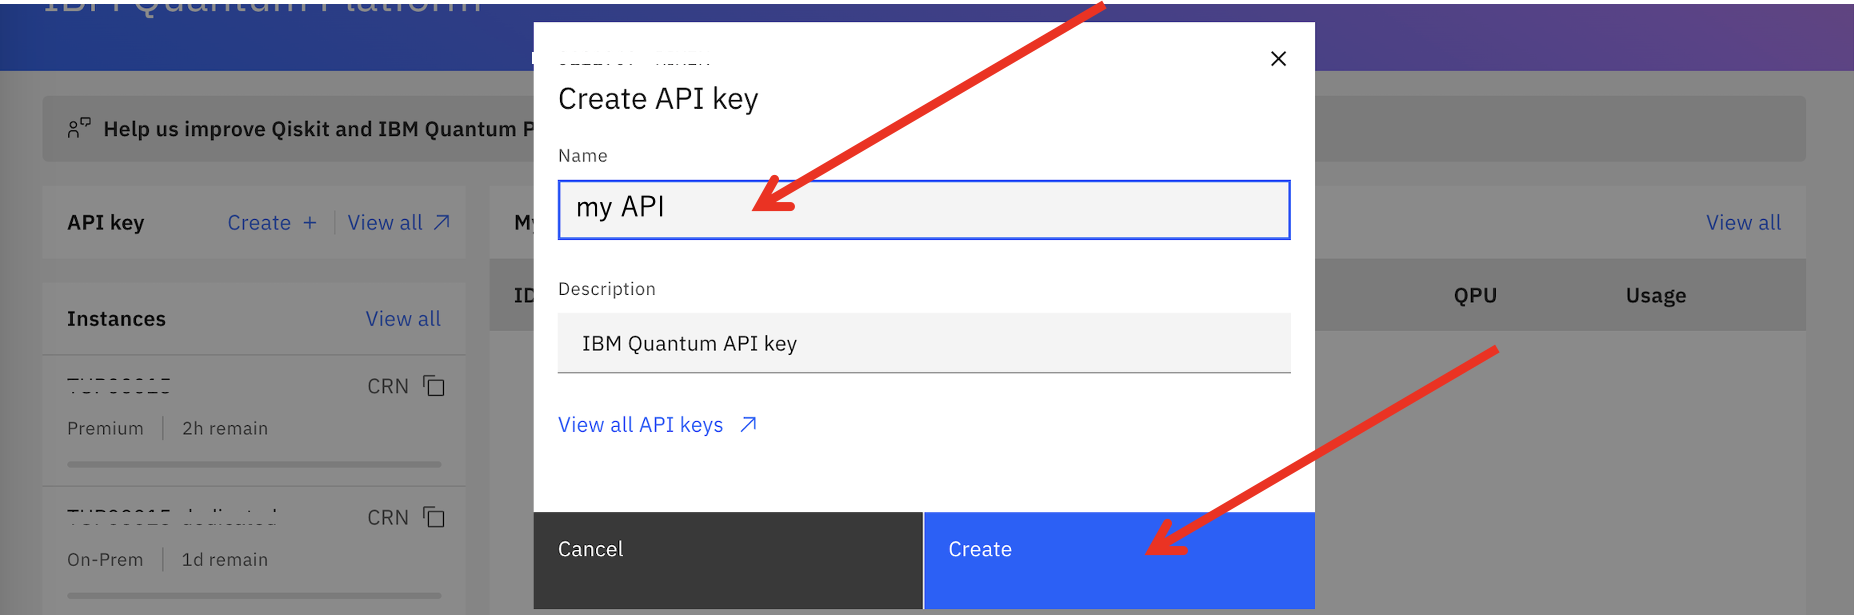

3) 「Download」をクリックして「apikey.json」ファイルを保存します。
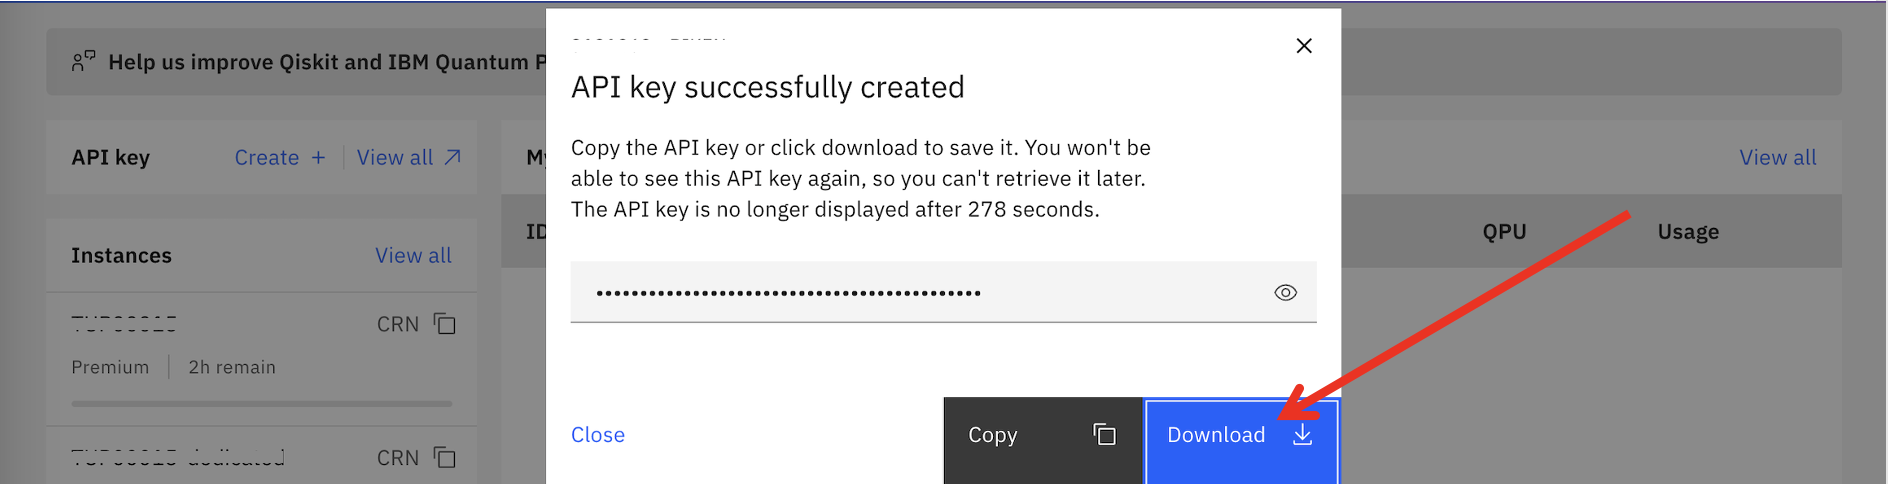

4) 先ほど保存した「apikey.json」ファイルから、apikeyをコピーして、次のセルの `deleteThisAndPasteYourAPIKeyHere` に上書きしてください。
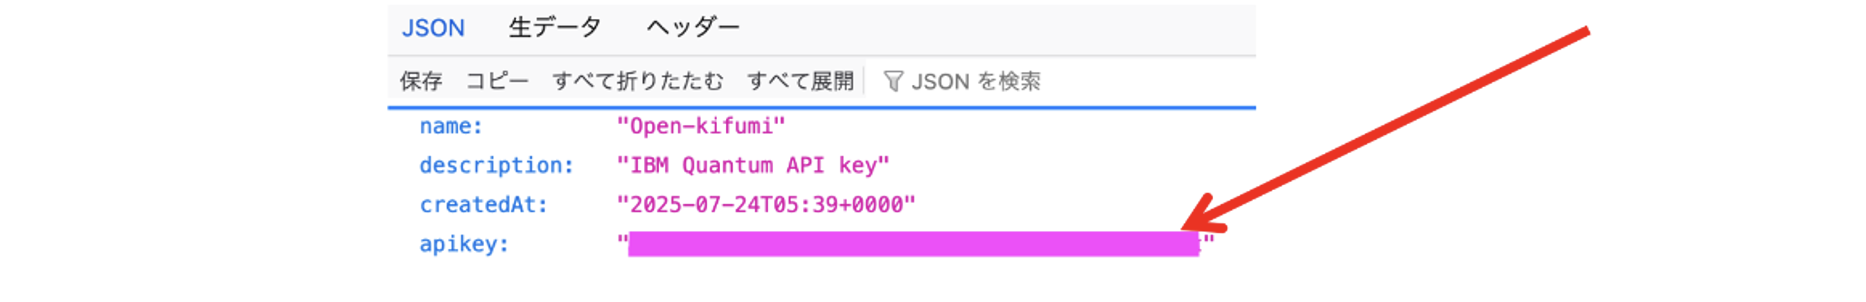

5) CRNをコピーして、次のセルの `deleteThisAndPasteYourCRNHere` に上書きしてください。
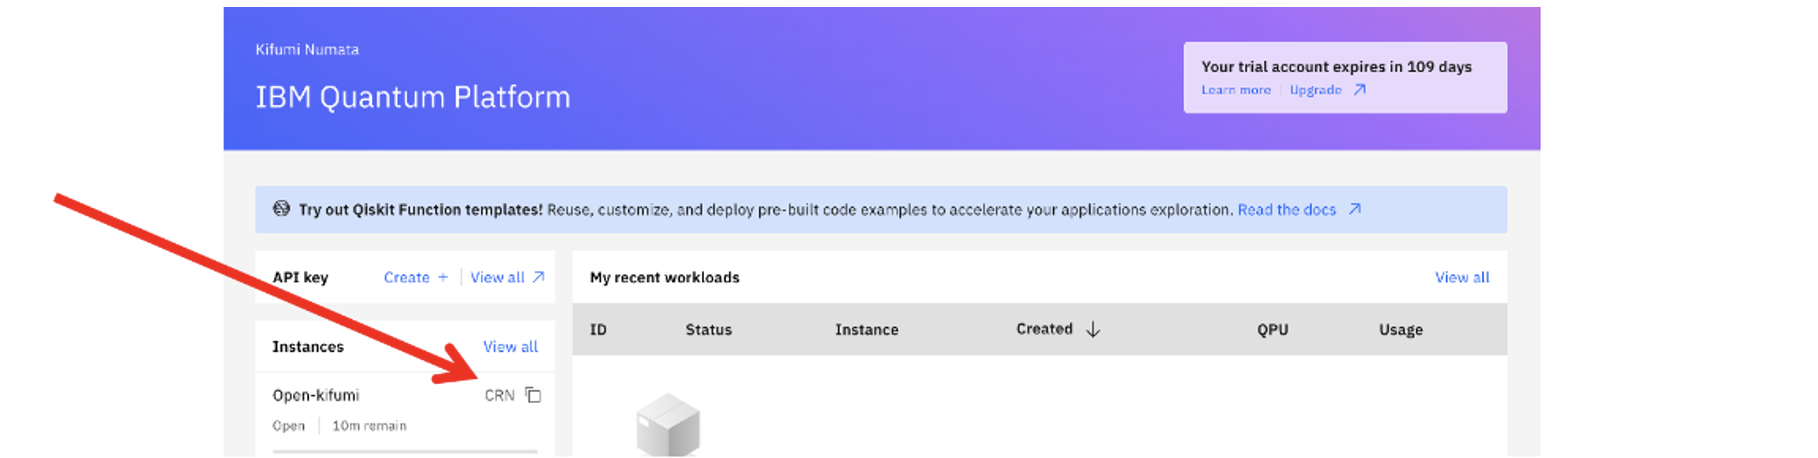

以下を実行してください。

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

your_api_key = "deleteThisAndPasteYourAPIKeyHere"
your_crn = "deleteThisAndPasteYourCRNHere"

service = QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token=your_api_key,
    instance=your_crn,
    set_as_default=True,
    overwrite=True,
    name = "nedo_q" 
)

続けて以下を実行すると、使うことのできる量子コンピューターのデバイスが表示されます。

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(name = "nedo_q") 
service.backends()

In [ ]:
# 以下でデバイスを指定できます。
backend = service.backend('ibm_marrakesh')

In [ ]:
#一番空いているバックエンドを自動的に選択することもできます
backend = service.least_busy(operational=True)
print("最も空いているバックエンドは: ", backend)

# 4. 実機の量子コンピューターで実行する


In [ ]:
# 実機のバックエンドでの実行に最適な回路に変換します
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc)
isa_circuit.draw("mpl", idle_wires=False)

In [ ]:
# Samplerで実行します
from qiskit_ibm_runtime import SamplerV2
sampler = SamplerV2(backend)
job = sampler.run([isa_circuit]) # デフォルトのshot数は4096です

print("job id:", job.job_id()) # 実行に時間がかかる場合のためにjob_idを表示します

In [ ]:
job = service.job(job.job_id()) 
#job = service.job("dap3aplr85ps73fg2dm0") # 例です。上に出力された自分のjob_idを入れて実行してください。
job.status() # ジョブの実行状態を確認します

上記のセルを何回か実行して、'DONE' が表示されたら、実機での実行が終わっているので、以下のセルを実行して結果を確認します。

In [ ]:
### 'DONE'になってから実行します ###
result = job.result()
print(result[0].data.c.get_counts())

In [ ]:
from qiskit.visualization import plot_histogram
plot_histogram(result[0].data.c.get_counts())

© IBM Corp., 2026